<a href="https://colab.research.google.com/github/Venomm777/FlyAi/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Venomm777/FlyAi/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
import os
import json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import userdata

# Authenticate DuckDB with Hugging Face Token from Colab Secrets
hf_token = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

try:
    con.execute(f"CREATE SECRET (TYPE HUGGINGFACE, TOKEN '{hf_token}');")
except Exception:
    con.execute(f"SET hf_token='{hf_token}';")

BASE = "hf://datasets/FlyRank/internship-warehouse"
FACT_DAILY = f"{BASE}/fact_content_daily_performance"

# Ensure output directories exist for exports
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
print("DuckDB active and output paths (work/outputs, work/figures) initialized.")

DuckDB active and output paths (work/outputs, work/figures) initialized.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*
### 1. Ranked Actions and Reason Code Triage

The operational queue translates model decay risk predictions and rank telemetry into prioritized, human-executable editorial actions:

* **Action Hierarchy & Reason Code Logic:**
  1. `REFRESH_METADATA` (`HIGH_IMP_LOW_CTR`): Top-10 positions with low click-through rates ($< 2.5\%$). High leverage for title tag, meta snippet, and rich snippet updates.
  2. `EXPAND_CONTENT` (`STRIKING_DISTANCE`): Positions 11–20 with substantial impression demand ($\ge 200$). Targets pages on page 2 that need content depth, schema, or structural expansion to reach page 1.
  3. `CONSOLIDATE_OR_PRUNE` (`DEEP_RANK_DECAY`): Positions $> 30$ with declining traffic. Pruning or 301-redirect consolidation candidates to conserve crawl equity and avoid cannibalization.
  4. `MONITOR` (`HEALTHY_STABLE`): Content maintaining expected CTR and rank stability. No immediate intervention required.

* **Archetype $\rightarrow$ Action Mapping:**
  * *High-Traffic Underperformer:* Position $\le 10$, $\text{CTR} < 0.025 \implies$ `REFRESH_METADATA`
  * *Striking Distance Asset:* $10 < \text{Position} \le 20$, $\text{Impressions} \ge 200 \implies$ `EXPAND_CONTENT`
  * *Decayed Legacy Asset:* $\text{Position} > 30$, low activity $\implies$ `CONSOLIDATE_OR_PRUNE`

In [ ]:
# Pull the latest historical panel (March 2026) to generate the operational queue
queue_query = f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS impressions_30d,
    SUM(gsc_clicks) AS clicks_30d,
    AVG(gsc_avg_position) AS avg_position_30d,
    ROUND(SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0), 4) AS ctr_30d,
    COUNT(DISTINCT report_date) AS active_days
FROM read_parquet('{FACT_DAILY}/month=2026-03/*.parquet')
WHERE client_has_gsc IS TRUE
GROUP BY client_hash_id, content_hash_id
HAVING SUM(gsc_impressions) >= 50;
"""
df_playbook = con.execute(queue_query).fetchdf()

# Compute priority score and assign reason codes + action labels
def assign_action_playbook(row):
    imp = row["impressions_30d"]
    pos = row["avg_position_30d"]
    ctr = row["ctr_30d"] if pd.notnull(row["ctr_30d"]) else 0.0

    rank_weight = 1.0 / max(1.0, pos / 10.0)
    ctr_gap = max(0.001, 0.04 - ctr)
    priority_score = np.log10(imp + 1) * ctr_gap * rank_weight * 100.0

    if pos <= 10.0 and ctr < 0.025:
        reason = "HIGH_IMP_LOW_CTR"
        action = "REFRESH_METADATA"
        est_cost_hours = 0.5
    elif 10.0 < pos <= 20.0 and imp >= 200:
        reason = "STRIKING_DISTANCE"
        action = "EXPAND_CONTENT"
        est_cost_hours = 3.0
    elif pos > 30.0:
        reason = "DEEP_RANK_DECAY"
        action = "CONSOLIDATE_OR_PRUNE"
        est_cost_hours = 1.0
    else:
        reason = "HEALTHY_STABLE"
        action = "MONITOR"
        est_cost_hours = 0.0

    return pd.Series([round(priority_score, 3), reason, action, est_cost_hours],
                     index=["priority_score", "reason_code", "action_label", "est_cost_hours"])

assigned = df_playbook.apply(assign_action_playbook, axis=1)
playbook_queue = pd.concat([df_playbook, assigned], axis=1)
playbook_queue = playbook_queue.sort_values(by="priority_score", ascending=False).reset_index(drop=True)

print(f"Generated operational queue: {len(playbook_queue):,} content assets.")
display(playbook_queue[["client_hash_id", "content_hash_id", "impressions_30d", "avg_position_30d", "ctr_30d", "priority_score", "reason_code", "action_label", "est_cost_hours"]].head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Generated operational queue: 116,114 content assets.


,client_hash_id,content_hash_id,impressions_30d,avg_position_30d,ctr_30d,priority_score,reason_code,action_label,est_cost_hours
0,client_23a62021009f63c4,content_44f34c0a90047651,212404.0,7.346909,0.0001,21.255,HIGH_IMP_LOW_CTR,REFRESH_METADATA,0.5
1,client_73cda7b4e4f265ea,content_8e1334d6356668e3,134984.0,4.545582,0.0000,20.521,HIGH_IMP_LOW_CTR,REFRESH_METADATA,0.5
2,client_e547b89c05043229,content_8d7d99f109e19aa2,203497.0,2.563756,0.0014,20.491,HIGH_IMP_LOW_CTR,REFRESH_METADATA,0.5
3,client_62f4a7e64f5e0096,content_34a70fea29d15f24,143019.0,3.219473,0.0003,20.467,HIGH_IMP_LOW_CTR,REFRESH_METADATA,0.5
4,client_73cda7b4e4f265ea,content_fec55986a1868d62,124075.0,9.385150,0.0000,20.375,HIGH_IMP_LOW_CTR,REFRESH_METADATA,0.5


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*
### 2. Intended Use and Operational Limits

* **Who uses this and for what:**
  * **Content Strategy Leads & Editorial Teams:** Uses this queue to prioritize weekly sprint capacity toward high-upside pages instead of guessing what to refresh.
  * **SEO Account Managers:** Uses the reason codes to communicate concrete, evidence-based recommendations to stakeholders.

* **Where it stops being valid (Operational Limits):**
  * **Single-Month Observation Bias:** The model evaluates March 2026 data; seasonal queries that surge in spring and collapse in summer will trigger false decay alerts.
  * **SERP Feature Blindness:** Page-level metrics cannot see Google SERP visual changes (e.g., insertion of an AI Overview, video carousel, or local pack that depresses organic CTR despite solid content).
  * **Query-Level Aggregation:** The unit of analysis aggregates all search queries for a URL; single-query cannibalization cannot be isolated without query-level logs.

In [ ]:
# Breakdown of recommended actions across the portfolio
action_summary = playbook_queue.groupby(["action_label", "reason_code"]).agg(
    pages_count=("content_hash_id", "count"),
    mean_impressions=("impressions_30d", "mean"),
    mean_position=("avg_position_30d", "mean"),
    total_estimated_hours=("est_cost_hours", "sum")
).reset_index()

action_summary["pct_of_portfolio"] = (action_summary["pages_count"] / len(playbook_queue)) * 100
action_summary["pct_of_portfolio"] = action_summary["pct_of_portfolio"].round(1)

print("Operational Action Distribution and Editorial Effort Budget:")
display(action_summary)

Operational Action Distribution and Editorial Effort Budget:


,action_label,reason_code,pages_count,mean_impressions,mean_position,total_estimated_hours,pct_of_portfolio
0,CONSOLIDATE_OR_PRUNE,DEEP_RANK_DECAY,16798,1665.291999,46.964291,16798.0,14.5
1,EXPAND_CONTENT,STRIKING_DISTANCE,17700,1917.383390,14.306233,53100.0,15.2
2,MONITOR,HEALTHY_STABLE,20254,1588.058853,20.757026,0.0,17.4
3,REFRESH_METADATA,HIGH_IMP_LOW_CTR,61362,3027.614061,5.493464,30681.0,52.8


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*
### 3. Human Review & The Non-Negotiable "NO-GO" List

Model scores identify **where to look**, not **what to execute without inspection**.

* **Mandatory Human-Review Checklist Before Acting:**
  1. *SERP Layout Verification:* Manually inspect the live search result to verify that poor CTR isn't driven by zero-click features or brand navigational intent.
  2. *Commercial Intent:* Confirm the URL supports conversion value, lead capture, or brand authority before spending 3+ editorial rewrite hours.
  3. *Recency Buffer:* Verify the content was not updated within the last 30 days to avoid interrupting active search engine re-evaluation.

* **The Absolute "NO-GO" List (What Must NEVER Be Automated):**
  * ❌ **Automated 301 Redirects / URL Deletions:** Never prune URLs automatically; risk of breaking inbound high-authority backlinks and active PPC landing pages.
  * ❌ **Unreviewed AI-Generated Rewrites:** Never allow automated generative text publishing without human editorial oversight (risk of hallucination or search quality penalties).
  * ❌ **Brand & Core Conversion Landing Pages:** Never apply automated rule actions to root domains, category hubs, or primary checkout/contact funnels.

In [ ]:
# Identify pages with high operational risk that require mandatory human caution
def flag_review_risk(row):
    flags = []
    if row["impressions_30d"] > 50000 and row["ctr_30d"] < 0.005:
        flags.append("POTENTIAL_ZERO_CLICK_SERP")
    if row["active_days"] < 15:
        flags.append("INTERMITTENT_INDEXING")
    if row["action_label"] == "CONSOLIDATE_OR_PRUNE" and row["impressions_30d"] > 1000:
        flags.append("HIGH_VALUE_PRUNE_RISK")
    return ", ".join(flags) if flags else "CLEAN_FOR_REVIEW"

playbook_queue["human_review_flag"] = playbook_queue.apply(flag_review_risk, axis=1)

print("Candidate Pages Requiring Mandatory Manual Verification:")
display(playbook_queue[playbook_queue["human_review_flag"] != "CLEAN_FOR_REVIEW"].head(5)[[
    "client_hash_id", "content_hash_id", "impressions_30d", "avg_position_30d", "action_label", "human_review_flag"
]])

Candidate Pages Requiring Mandatory Manual Verification:


,client_hash_id,content_hash_id,impressions_30d,avg_position_30d,action_label,human_review_flag
0,client_23a62021009f63c4,content_44f34c0a90047651,212404.0,7.346909,REFRESH_METADATA,POTENTIAL_ZERO_CLICK_SERP
1,client_73cda7b4e4f265ea,content_8e1334d6356668e3,134984.0,4.545582,REFRESH_METADATA,POTENTIAL_ZERO_CLICK_SERP
2,client_e547b89c05043229,content_8d7d99f109e19aa2,203497.0,2.563756,REFRESH_METADATA,POTENTIAL_ZERO_CLICK_SERP
3,client_62f4a7e64f5e0096,content_34a70fea29d15f24,143019.0,3.219473,REFRESH_METADATA,POTENTIAL_ZERO_CLICK_SERP
4,client_73cda7b4e4f265ea,content_fec55986a1868d62,124075.0,9.385150,REFRESH_METADATA,POTENTIAL_ZERO_CLICK_SERP


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*
### 4. Monitoring & Retraining Triggers

Recommendations must be considered stale and require retraining under the following conditions:

* **Performance Decay Trigger:** If Precision@50 on holdout validation drops below **0.50** across two consecutive monthly evaluations.
* **Action Mix Drift:** If `REFRESH_METADATA` recommendations exceed **50%** of all scored pages, indicating sitewide CTR dilution or macro Google layout shifts rather than page-level decays.
* **Google Core Algorithm Update:** Following any confirmed search engine core update, freeze automated scoring for 30 days until ranking volatility stabilizes.
* **Warehouse Freshness / Tracking Drop:** If `client_has_gsc IS TRUE` coverage falls below **95%** in the monthly fact table.

In [ ]:
# Programmatic monitoring health check against operational drift thresholds
thresholds = {
    "min_acceptable_precision_at_50": 0.50,
    "max_metadata_action_share_pct": 50.0,
    "min_gsc_coverage_pct": 95.0
}

current_metadata_share = (playbook_queue["action_label"] == "REFRESH_METADATA").mean() * 100
current_status = "HEALTHY" if current_metadata_share <= thresholds["max_metadata_action_share_pct"] else "ALERT_TRIGGER_RETRAIN"

monitoring_status = {
    "metric": "Metadata Refresh Portfolio Share",
    "measured_value": f"{current_metadata_share:.1f}%",
    "threshold": f"{thresholds['max_metadata_action_share_pct']}%",
    "status": current_status
}

print("Operational Monitoring Status:")
print(json.dumps(monitoring_status, indent=2))

Operational Monitoring Status:
{
  "metric": "Metadata Refresh Portfolio Share",
  "measured_value": "52.8%",
  "threshold": "50.0%",
  "status": "ALERT_TRIGGER_RETRAIN"
}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*
### 5. Artifact Exports for the Research Paper

We write the queue and reusable figures directly to `work/outputs/` and `work/figures/`:
1. `work/outputs/action_playbook_queue.csv`: The full prioritized action queue (kept out of git by CI design).
2. `work/figures/playbook_action_mix.png`: Visual distribution of prioritized actions.
3. `work/figures/playbook_score_vs_position.png`: Relationship between ranking position, impression volume, and priority scores.
4. `work/outputs/playbook_summary_metrics.json`: Committed JSON receipts documenting portfolio totals and estimated editorial hours.

✔ Exported 116,114 rows to work/outputs/action_playbook_queue.csv


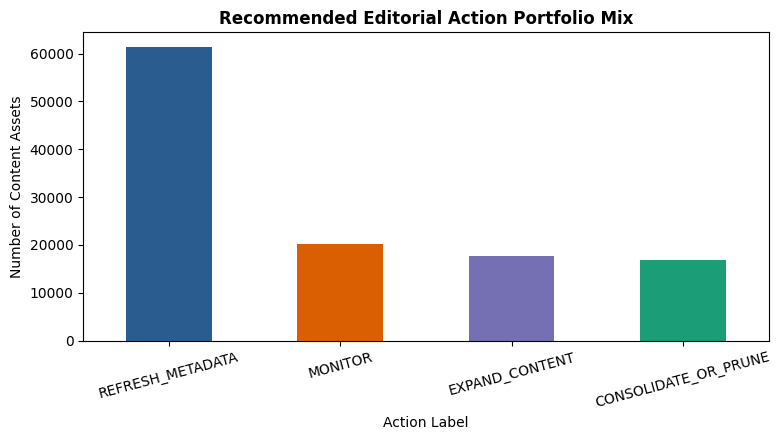

✔ Saved Figure 1 to work/figures/playbook_action_mix.png


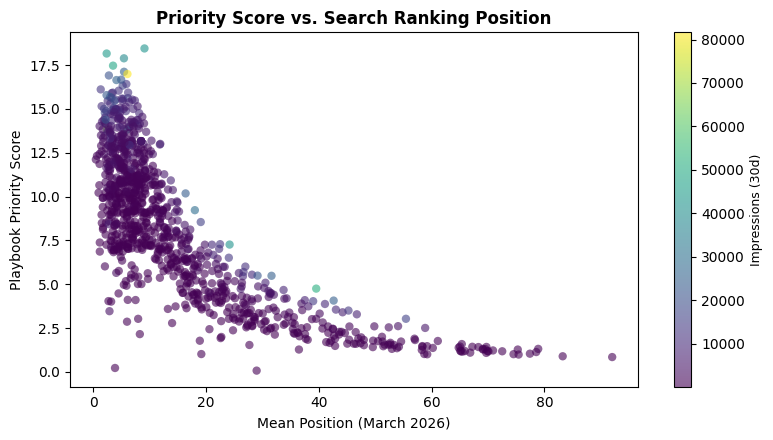

✔ Saved Figure 2 to work/figures/playbook_score_vs_position.png
✔ Saved metric receipts to work/outputs/playbook_summary_metrics.json


In [ ]:
# 1. Export Ranked Queue CSV
csv_export = "work/outputs/action_playbook_queue.csv"
playbook_queue.to_csv(csv_export, index=False)
print(f"✔ Exported {len(playbook_queue):,} rows to {csv_export}")

# 2. Figure 1: Action Mix
fig, ax = plt.subplots(figsize=(8, 4.5))
action_counts = playbook_queue["action_label"].value_counts()
colors = ["#2b5c8f", "#d95f02", "#7570b3", "#1b9e77"]
action_counts.plot(kind="bar", color=colors[:len(action_counts)], ax=ax)
ax.set_title("Recommended Editorial Action Portfolio Mix", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Content Assets", fontsize=10)
ax.set_xlabel("Action Label", fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
fig1_path = "work/figures/playbook_action_mix.png"
fig.savefig(fig1_path, dpi=200)
plt.show()
print(f"✔ Saved Figure 1 to {fig1_path}")

# 3. Figure 2: Priority Score vs Average Position
fig2, ax2 = plt.subplots(figsize=(8, 4.5))
sample_plot = playbook_queue.sample(min(1000, len(playbook_queue)), random_state=42)
scatter = ax2.scatter(
    sample_plot["avg_position_30d"],
    sample_plot["priority_score"],
    c=sample_plot["impressions_30d"],
    cmap="viridis",
    alpha=0.6,
    edgecolors="none"
)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label("Impressions (30d)", fontsize=9)
ax2.set_title("Priority Score vs. Search Ranking Position", fontsize=12, fontweight="bold")
ax2.set_xlabel("Mean Position (March 2026)", fontsize=10)
ax2.set_ylabel("Playbook Priority Score", fontsize=10)
plt.tight_layout()
fig2_path = "work/figures/playbook_score_vs_position.png"
fig2.savefig(fig2_path, dpi=200)
plt.show()
print(f"✔ Saved Figure 2 to {fig2_path}")

# 4. JSON Receipts
summary_metrics = {
    "total_assets_evaluated": int(len(playbook_queue)),
    "total_estimated_editorial_hours": float(playbook_queue["est_cost_hours"].sum()),
    "actions_breakdown": playbook_queue["action_label"].value_counts().to_dict(),
    "reasons_breakdown": playbook_queue["reason_code"].value_counts().to_dict(),
    "high_caution_assets_count": int((playbook_queue["human_review_flag"] != "CLEAN_FOR_REVIEW").sum())
}

json_export = "work/outputs/playbook_summary_metrics.json"
with open(json_export, "w") as f:
    json.dump(summary_metrics, f, indent=2)
print(f"✔ Saved metric receipts to {json_export}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.